In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

In [3]:
(X_train,Y_train),(X_test,Y_test)=datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print('first 10 labels:',Y_train[:10])

first 10 labels: [9 0 0 3 0 2 7 2 5 5]


In [5]:
class_names=[
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
for i ,name in enumerate(class_names):
    print(i,"->",name)

0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat
5 -> Sandal
6 -> Shirt
7 -> Sneaker
8 -> Bag
9 -> Ankle boot


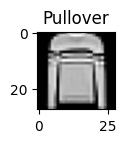

In [6]:
plt.figure(figsize=(1,2))
plt.imshow(X_train[5],cmap="gray")
plt.title(class_names[Y_train[5]])
plt.show()

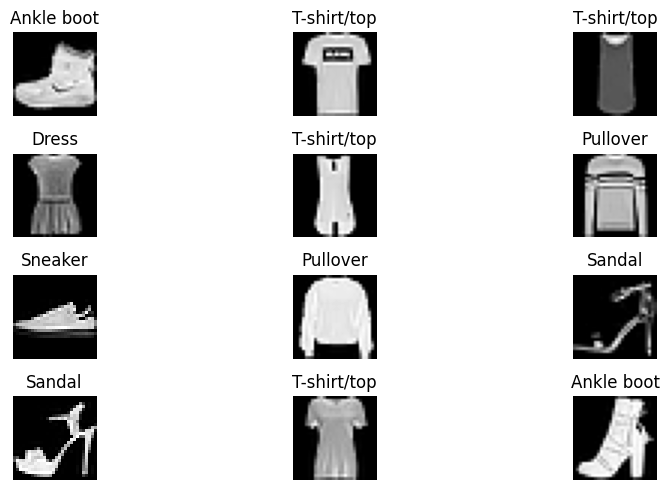

In [7]:
plt.figure(figsize=(10,5))
for i in range(12):
  plt.subplot(4,3,i+1)
  plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
  plt.title(class_names[Y_train[i]])
  plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
print("miniumn pixel value",X_train.min())
print("maximum pixel value",X_train.max())

miniumn pixel value 0
maximum pixel value 255


In [9]:
X_train=X_train.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0
print("miniumn pixel value",X_train.min())
print("maximum pixel value",X_train.max())

miniumn pixel value 0.0
maximum pixel value 1.0


In [10]:
X_train=np.expand_dims(X_train,axis=-1)
X_test=np.expand_dims(X_test,axis=-1)
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [11]:
cnn=models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10,activation="softmax")


])

In [12]:
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
from sklearn.utils import validation
history=cnn.fit(
    X_train,Y_train,
    epochs=15,validation_split=0.1,batch_size=64
)



Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7806 - loss: 0.6105 - val_accuracy: 0.8567 - val_loss: 0.3848
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8569 - loss: 0.3993 - val_accuracy: 0.8873 - val_loss: 0.3129
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8743 - loss: 0.3503 - val_accuracy: 0.8930 - val_loss: 0.2876
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8846 - loss: 0.3143 - val_accuracy: 0.8957 - val_loss: 0.2789
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8931 - loss: 0.2920 - val_accuracy: 0.8948 - val_loss: 0.2784
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9002 - loss: 0.2736 - val_accuracy: 0.9065 - val_loss: 0.2548
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9054 - loss: 0.2546 - val_accuracy: 0.9068 - val_loss: 0.2521
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9114 - loss: 0.2417 - val_accuracy: 0

<function matplotlib.pyplot.show(close=None, block=None)>

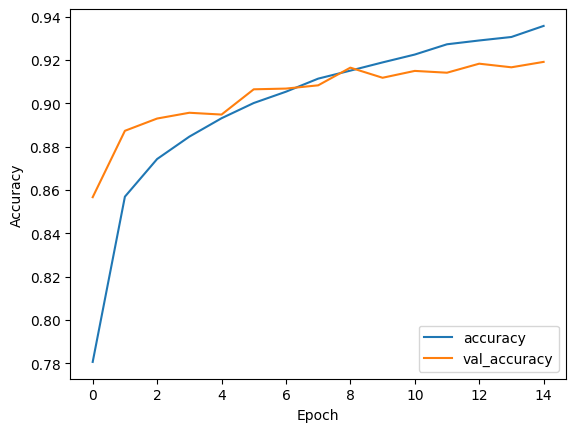

In [14]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.show

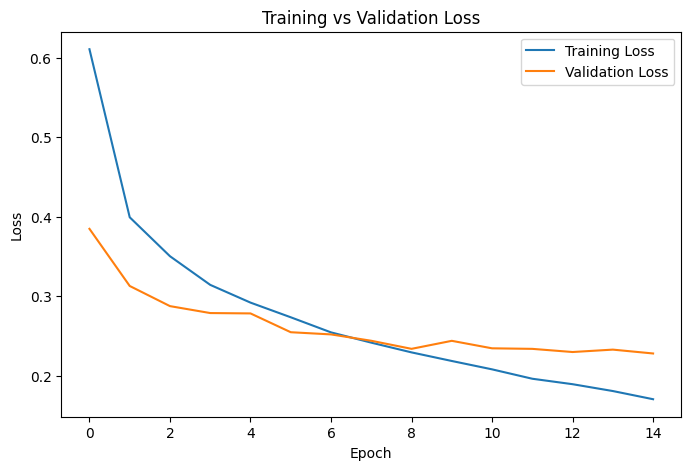

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [17]:
test_loss, test_accuracy = cnn.evaluate(X_test, Y_test)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9138 - loss: 0.2446
Test Loss     : 0.24457287788391113
Test Accuracy : 0.9138000011444092


In [19]:
y_pred_prob = cnn.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 predicted labels:", y_pred[:10])
print("First 10 actual labels   :", Y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 10 predicted labels: [9 2 1 1 6 1 4 6 5 7]
First 10 actual labels   : [9 2 1 1 6 1 4 6 5 7]


In [20]:
for i in range(10):
    print(
        f"Image {i}: "
        f"Actual = {class_names[Y_test[i]]}, "
        f"Predicted = {class_names[y_pred[i]]}"
    )

Image 0: Actual = Ankle boot, Predicted = Ankle boot
Image 1: Actual = Pullover, Predicted = Pullover
Image 2: Actual = Trouser, Predicted = Trouser
Image 3: Actual = Trouser, Predicted = Trouser
Image 4: Actual = Shirt, Predicted = Shirt
Image 5: Actual = Trouser, Predicted = Trouser
Image 6: Actual = Coat, Predicted = Coat
Image 7: Actual = Shirt, Predicted = Shirt
Image 8: Actual = Sandal, Predicted = Sandal
Image 9: Actual = Sneaker, Predicted = Sneaker


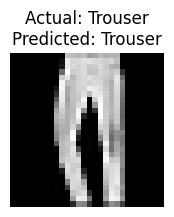

In [22]:
index = 5

plt.figure(figsize=(2,2))
plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.title(
    f"Actual: {class_names[Y_test[index]]}\n"
    f"Predicted: {class_names[y_pred[index]]}"
)
plt.axis("off")
plt.show()

In [24]:
print(
    classification_report(
        Y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.90      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.88      0.87      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.89      0.85      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.71      0.73      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



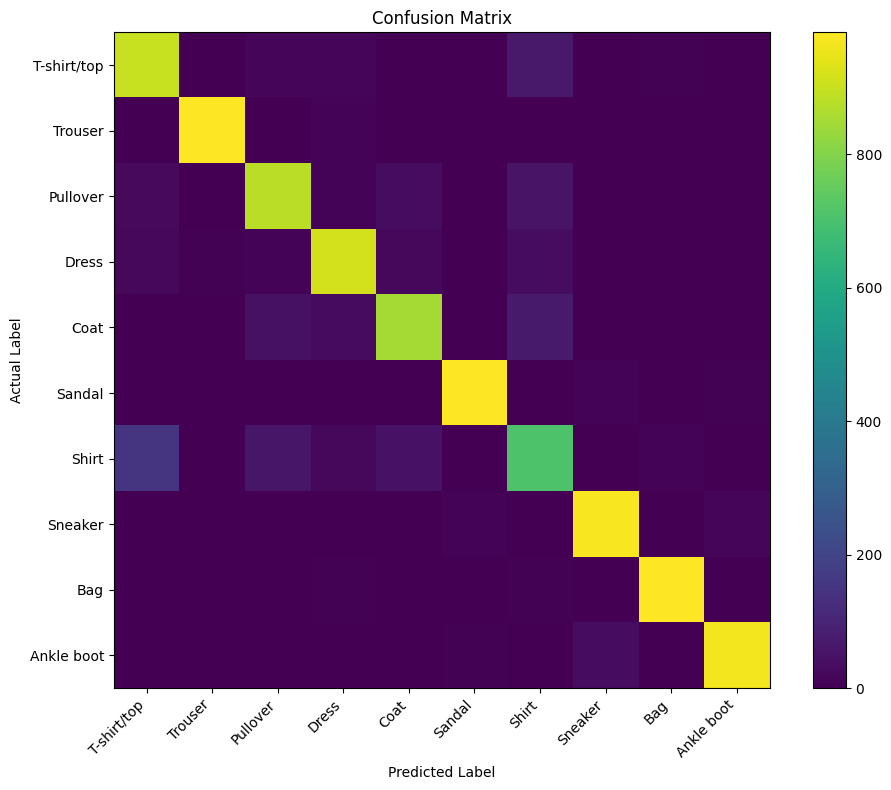

In [26]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
wrong_indices = np.where(Y_test != y_pred)[0]

print("Number of incorrect predictions:", len(wrong_indices))
print("First 10 incorrect indices:", wrong_indices[:10])

Number of incorrect predictions: 862
First 10 incorrect indices: [ 21  23  25  42  49  67  68  89  98 103]


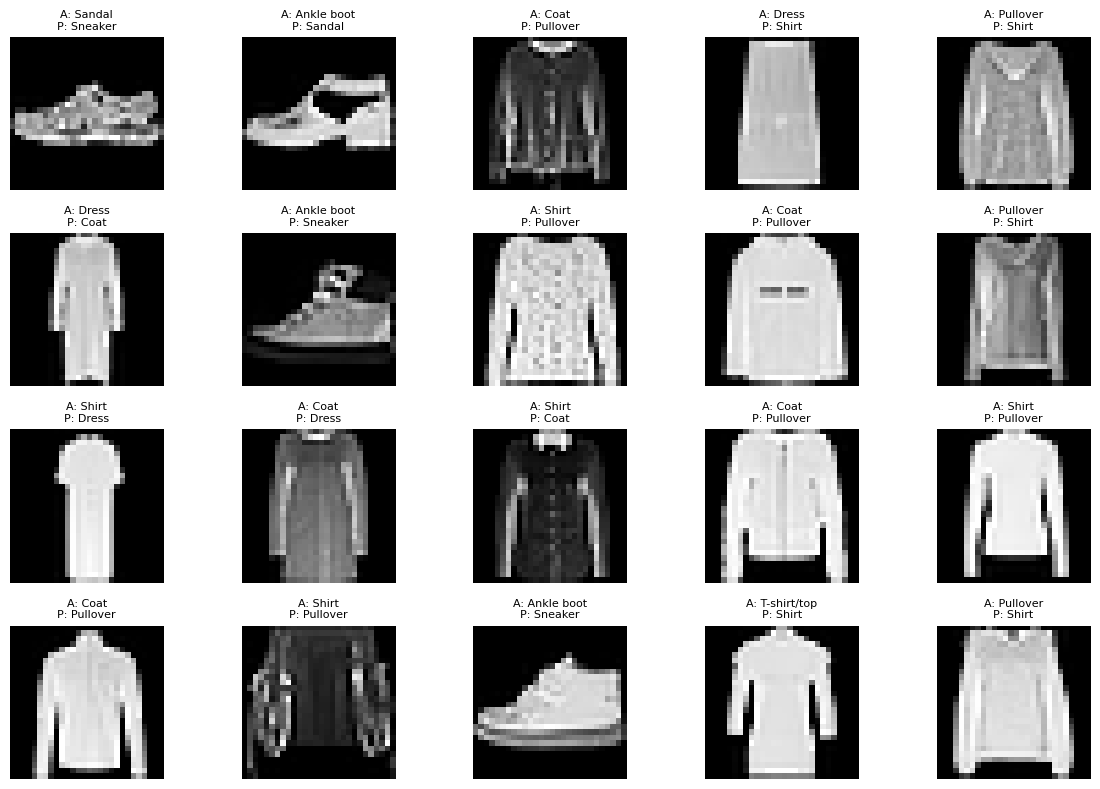

In [30]:
plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indices[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    actual = class_names[Y_test[idx]]
    predicted = class_names[y_pred[idx]]

    plt.title(f"A: {actual}\nP: {predicted}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()